# 现代推理系统

> Part 3 的推理加速一节讲了单次推理的算子层优化——KV Cache、FlashAttention、算子融合。那是「一个请求」的视角。
>
> 这一节换到「服务多个请求」的视角。当 100 个用户同时向同一个模型发请求，单卡怎么扛住？答案是一组系统层技术：PagedAttention 解决显存碎片，Continuous batching 解决吞吐，Prefix caching 解决重复前缀，Prefill/Decode 分离解决两种计算模式的资源冲突。这一节从服务指标出发，逐个拆开看。

LLM 推理服务和传统的 web 服务不一样。传统 web 服务每个请求计算量小、延迟低，可以用一个进程池简单应付。LLM 推理每个请求要生成几百到几千个 token，每个 token 都要跑一次完整的 forward pass，单卡同时只能服务有限的并发——多了显存爆，少了吞吐低。

服务质量的衡量指标因此也不一样。**吞吐**（throughput，每秒生成的 token 总数）关心总产能；**首 token 延迟**（TTFT，time to first token）关心用户等第一句话要等多久；**每 token 延迟**（TPOT，time per output token）关心生成过程中的流畅度。这三个指标互相牵制，不可能同时全优。

现代推理系统的主要工作就是在这些指标之间找平衡。下面几节按「问题—解决」的顺序展开：先看 KV Cache 在多请求下的碎片问题，再看 PagedAttention 怎么解决；然后看 Continuous batching 怎么把吞吐拉满；最后看 Prefix caching 和 Prefill/Decode 分离这两个更现代的优化。

## 1. 服务指标：吞吐、延迟、并发

把指标定义清楚再谈优化。LLM 服务常用四个指标：

| 指标 | 全称 | 含义 | 关心的人 |
|:---|:---|:---|:---|
| **吞吐** | Throughput | 每秒生成的 token 总数（跨所有请求） | 服务方（成本） |
| **TTFT** | Time To First Token | 用户发请求到收到第一个 token 的时间 | 用户体验 |
| **TPOT** | Time Per Output Token | 生成过程中每个 token 的平均间隔 | 用户体验 |
| **并发数** | Concurrency | 同时在服务的请求数 | 容量规划 |

它们之间的关系不是独立的。固定 GPU 算力下，并发翻倍通常让吞吐接近翻倍，但 TPOT 也会变差——每个请求分到的算力更少。TTFT 主要受 prefill 阶段影响，TPOT 主要受 decode 阶段影响。Prefill 是一次性算完整个 prompt（计算密集），decode 是逐个生成（带宽密集），这两种计算模式的资源使用完全不同，第 6 节会展开。

下面用一组具体数字感受这些指标的量级。

In [1]:
# 服务指标的具体数字感
# 假设：A100 GPU（80GB），Llama-7B FP16，batch=32

gpu_tflops = 312       # A100 FP16 峰值算力
params = 7e9           # Llama-7B 参数量
flops_per_token = 2 * 2 * params   # 推理一次 token 的 FLOPs（2×参数×batch，前后向合并到一次推理）
batch_size = 32

# decode 阶段：每秒能跑多少 forward
# 注意：实际 decode 是 memory-bound，这里只算 compute 上限
flops_per_forward = flops_per_token * batch_size
compute_limit = gpu_tflops * 1e12 / flops_per_forward

print(f"=== A100 + Llama-7B + batch={batch_size} ===")
print(f"GPU 算力: {gpu_tflops} TFLOPS (FP16)")
print(f"每 token forward FLOPs: {flops_per_token:.2e}")
print(f"Batch={batch_size} 时每次 forward FLOPs: {flops_per_forward:.2e}")
print(f"Compute 上限: 每秒 {compute_limit:.1f} 次 forward")
print(f"理论吞吐上限: {compute_limit * batch_size:.0f} tokens/s")
print()

# 实际 decode 是 memory-bound，受显存带宽限制
gpu_bw_gbs = 2000     # A100 显存带宽 ~2 TB/s
bytes_per_token = params * 2  # FP16，读一遍权重
bw_limit = gpu_bw_gbs * 1e9 / bytes_per_token  # 每秒能读多少 token

print(f"显存带宽: {gpu_bw_gbs} GB/s")
print(f"每 token 要读: {bytes_per_token / 1e9:.1f} GB（权重）")
print(f"Memory 上限: {bw_limit:.0f} tokens/s（单流）")
print(f"Batch={batch_size} 时: {bw_limit * batch_size:.0f} tokens/s（带宽复用）")
print()
print(f"关键观察：算力上限 ({compute_limit * batch_size:.0f}) 远高于带宽限制")
print(f"实际瓶颈在显存带宽——这就是为什么 KV Cache 大小如此重要")

=== A100 + Llama-7B + batch=32 ===
GPU 算力: 312 TFLOPS (FP16)
每 token forward FLOPs: 2.80e+10
Batch=32 时每次 forward FLOPs: 8.96e+11
Compute 上限: 每秒 348.2 次 forward
理论吞吐上限: 11143 tokens/s

显存带宽: 2000 GB/s
每 token 要读: 14.0 GB（权重）
Memory 上限: 143 tokens/s（单流）
Batch=32 时: 4571 tokens/s（带宽复用）

关键观察：算力上限 (11143) 远高于带宽限制
实际瓶颈在显存带宽——这就是为什么 KV Cache 大小如此重要


## 2. KV Cache 碎片问题

回顾 Part 3 推理加速一节里的 KV Cache：每个请求生成过程中，所有历史 token 的 K、V 都要缓存。当多个请求同时在服务时，每个请求的 KV Cache 大小都不一样——有的 prompt 短（100 token），有的长（10K token），生成长度也参差不齐。

最朴素的内存管理是**连续分配**：给每个请求划一段连续的显存空间。这种方式有两个问题。第一是**内部碎片**：请求需要 100 token，但分配粒度按 page（比如 16 token），实际分到 112 token 的空间，浪费 12 token。第二是**外部碎片**：一个请求结束释放的空间，下一个请求可能因为大小不匹配用不上，造成总空间够但无法分配的尴尬。

这和操作系统的内存管理问题完全一样。OS 的解决方案是**分页**——把物理内存切成固定大小的页，逻辑地址通过 page table 映射到物理页，不需要连续。vLLM 把这个思想搬到了 KV Cache 上，叫 **PagedAttention**。

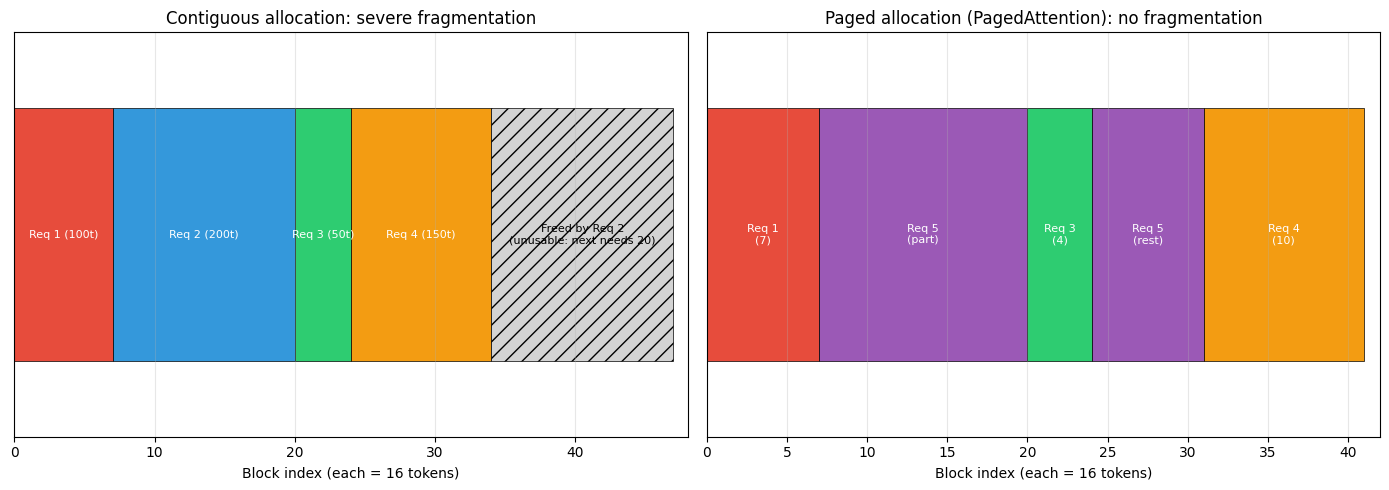

关键观察：
  连续分配：Req 2 释放的 13 块没法给需要 20 块的 Req 5 → 等待或拒绝
  分页分配：Req 5 拿 13 块（来自 Req 2 释放）+ 7 块（其他空闲）= 20 块，立刻可用


In [2]:
# 可视化连续分配 vs 分页分配的碎片问题

import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 连续分配（左图）
ax = axes[0]
ax.set_title("Contiguous allocation: severe fragmentation", fontsize=12)

# 4 个请求，块数分别为 7, 13, 4, 10
sizes = [7, 13, 4, 10]
labels = ['Req 1 (100t)', 'Req 2 (200t)', 'Req 3 (50t)', 'Req 4 (150t)']
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
start = 0
for size, label, color in zip(sizes, labels, colors):
    rect = patches.Rectangle((start, 0), size, 1, facecolor=color, edgecolor='black', linewidth=0.5)
    ax.add_patch(rect)
    ax.text(start + size/2, 0.5, label, ha='center', va='center', fontsize=8, color='white')
    start += size
# 假设 Req 2 完成，释放了 13 块，但下一个请求需要 20 块——放不下
rect = patches.Rectangle((start, 0), 13, 1, facecolor='lightgray', hatch='//', edgecolor='black', linewidth=0.5)
ax.add_patch(rect)
ax.text(start + 6.5, 0.5, 'Freed by Req 2\n(unusable: next needs 20)', ha='center', va='center', fontsize=8)
start += 13

ax.set_xlim(0, start + 1)
ax.set_ylim(-0.3, 1.3)
ax.set_xlabel('Block index (each = 16 tokens)')
ax.set_yticks([])
ax.grid(True, axis='x', alpha=0.3)

# 分页分配（右图）
ax = axes[1]
ax.set_title("Paged allocation (PagedAttention): no fragmentation", fontsize=12)

# 请求可以拿任意块，不需要连续
# 假设一个新请求 Req 5 需要 20 块，可以用 Req 2 释放的 13 块 + 其他空闲块
layout = [
    ('Req 1\n(7)', '#e74c3c', 7),
    ('Req 5\n(part)', '#9b59b6', 13),   # 用了 Req 2 释放的 13 块
    ('Req 3\n(4)', '#2ecc71', 4),
    ('Req 5\n(rest)', '#9b59b6', 7),    # 再用 7 块
    ('Req 4\n(10)', '#f39c12', 10),
]
start = 0
for label, color, n in layout:
    rect = patches.Rectangle((start, 0), n, 1, facecolor=color, edgecolor='black', linewidth=0.5)
    ax.add_patch(rect)
    ax.text(start + n/2, 0.5, label, ha='center', va='center', fontsize=8, color='white')
    start += n

ax.set_xlim(0, start + 1)
ax.set_ylim(-0.3, 1.3)
ax.set_xlabel('Block index (each = 16 tokens)')
ax.set_yticks([])
ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("关键观察：")
print("  连续分配：Req 2 释放的 13 块没法给需要 20 块的 Req 5 → 等待或拒绝")
print("  分页分配：Req 5 拿 13 块（来自 Req 2 释放）+ 7 块（其他空闲）= 20 块，立刻可用")

## 3. PagedAttention：把 OS 分页搬到 KV Cache

PagedAttention 的核心机制是 **block table**：每个请求维护一张表，记录自己的「逻辑 KV 序列」对应哪些物理块。物理块在显存里可以分散存放，不需要连续。

具体来说：
- 把显存切成固定大小的 **block**（vLLM 默认 16 token / block）
- 每个请求有一张 **block table**：`block_table[req_id][i]` = 第 i 个逻辑块对应的物理块 ID
- attention 计算时，根据 block table 把分散的物理块取出来，做正常的 attention

代价是 attention kernel 变复杂——要额外做一次 block table 查找。但收益远大于代价：碎片消失，显存利用率从 ~40% 提升到 ~95% 以上。

下面用一个简化的 Python 模拟器展示 block allocator 怎么工作。

In [3]:
# PagedAttention 简化模拟器：block-level KV cache 分配

class SimplePagedAttention:
    """简化版 PagedAttention 的 block allocator

    每个 block 容纳固定数量 token 的 KV cache。
    请求可以拿任意 block，不需要连续。
    """
    def __init__(self, num_blocks, block_size):
        self.num_blocks = num_blocks
        self.block_size = block_size
        self.free_blocks = list(range(num_blocks))  # 空闲块列表
        self.block_table = {}  # block_table[req_id] = [block_id_1, ...]
        print(f"初始化: {num_blocks} blocks × {block_size} tokens/block = {num_blocks * block_size} token 容量")

    def allocate(self, req_id, num_tokens):
        """给一个请求分配 KV cache 空间"""
        num_blocks_needed = (num_tokens + self.block_size - 1) // self.block_size
        if num_blocks_needed > len(self.free_blocks):
            raise MemoryError(f"显存不足: 需要 {num_blocks_needed} 块，剩余 {len(self.free_blocks)} 块")

        blocks = [self.free_blocks.pop(0) for _ in range(num_blocks_needed)]
        self.block_table[req_id] = blocks
        print(f"  请求 {req_id}: 分配 {num_blocks_needed} 块 = {blocks}（需要 {num_tokens} tokens）")
        return blocks

    def free(self, req_id):
        """请求结束，释放所有块"""
        blocks = self.block_table.pop(req_id, [])
        self.free_blocks.extend(blocks)
        print(f"  请求 {req_id}: 释放 {len(blocks)} 块 = {blocks}")

    def status(self):
        used = self.num_blocks - len(self.free_blocks)
        print(f"  当前: {used}/{self.num_blocks} 块已用 ({used/self.num_blocks*100:.0f}%)")


print("=== PagedAttention 模拟 ===")
print()
pa = SimplePagedAttention(num_blocks=32, block_size=16)

print("\n阶段 1: 三个请求同时来")
pa.allocate("req-A", 100)   # 需要 7 块
pa.allocate("req-B", 50)    # 需要 4 块
pa.allocate("req-C", 200)   # 需要 13 块
pa.status()

print("\n阶段 2: req-B 完成，释放")
pa.free("req-B")
pa.status()

print("\n阶段 3: 新请求 req-D 来，需要 30 token = 2 块")
pa.allocate("req-D", 30)
pa.status()

print()
print("关键观察：req-D 复用了 req-B 释放的块，没有碎片问题")

=== PagedAttention 模拟 ===

初始化: 32 blocks × 16 tokens/block = 512 token 容量

阶段 1: 三个请求同时来
  请求 req-A: 分配 7 块 = [0, 1, 2, 3, 4, 5, 6]（需要 100 tokens）
  请求 req-B: 分配 4 块 = [7, 8, 9, 10]（需要 50 tokens）
  请求 req-C: 分配 13 块 = [11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]（需要 200 tokens）
  当前: 24/32 块已用 (75%)

阶段 2: req-B 完成，释放
  请求 req-B: 释放 4 块 = [7, 8, 9, 10]
  当前: 20/32 块已用 (62%)

阶段 3: 新请求 req-D 来，需要 30 token = 2 块
  请求 req-D: 分配 2 块 = [24, 25]（需要 30 tokens）
  当前: 22/32 块已用 (69%)

关键观察：req-D 复用了 req-B 释放的块，没有碎片问题


## 4. Continuous batching：动态拼 batch

传统 batching（也叫 static batching）的做法是：攒一批请求一起跑，等所有请求都生成完毕才能加入新请求。问题是 batch 里如果有短请求和长请求混在一起，短请求跑完后这块算力就闲着，要等最长的那个跑完才能凑下一批。

**Continuous batching** 改成 iteration-level 调度：每生成一个 token 后，检查当前 batch——完成的请求立刻移出，新到的请求立刻加入。batch 大小动态变化，GPU 始终保持高利用率。

这个想法在 Orca 论文（OSDI 2022）里被系统化提出，vLLM、SGLang、TGI 等几乎所有现代推理引擎都实现了。

Static batching 总时间: 14 步
Continuous batching 总时间: 12 步
加速比: 1.17×



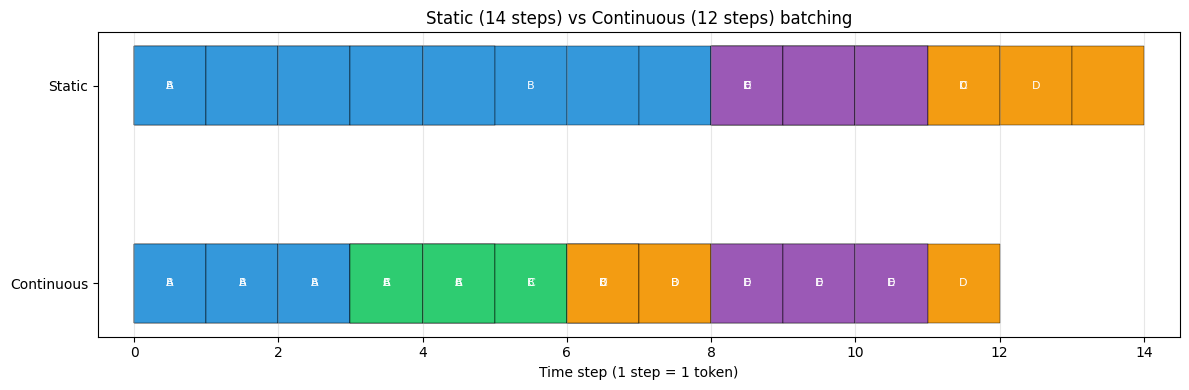

关键观察：Continuous batching 让短请求先结束、新请求立刻加入，总时间显著缩短


In [4]:
# Static batching vs Continuous batching 的简化对比

# 5 个请求，到达时间和生成长度都不同
requests = [
    {"id": "A", "arrival": 0, "tokens": 5},
    {"id": "B", "arrival": 0, "tokens": 8},
    {"id": "C", "arrival": 3, "tokens": 4},
    {"id": "D", "arrival": 6, "tokens": 6},
    {"id": "E", "arrival": 8, "tokens": 3},
]

# === Static batching ===
# 把同时到达的请求组成 batch，等到 batch 里最长的跑完才能加入新请求
def simulate_static(requests):
    time = 0
    pending = sorted(requests, key=lambda r: r["arrival"])
    timeline = []
    while pending:
        # 收集当前可以一起跑的请求
        batch = []
        while pending and pending[0]["arrival"] <= time:
            r = pending.pop(0)
            r["remaining"] = r["tokens"]
            batch.append(r)
        if not batch:
            timeline.append([])
            time += 1
            continue
        # 跑到最长那个结束
        max_len = max(r["remaining"] for r in batch)
        for t in range(max_len):
            timeline.append([r["id"] for r in batch if r["remaining"] > 0])
            for r in batch:
                r["remaining"] -= 1
            time += 1
    return timeline

# === Continuous batching ===
def simulate_continuous(requests):
    time = 0
    active = []
    pending = sorted(requests, key=lambda r: r["arrival"])
    timeline = []
    while pending or active:
        # 加入到达的请求
        while pending and pending[0]["arrival"] <= time:
            r = pending.pop(0)
            r["remaining"] = r["tokens"]
            active.append(r)
        # 一步生成
        if active:
            timeline.append([r["id"] for r in active])
            for r in active:
                r["remaining"] -= 1
            active = [r for r in active if r["remaining"] > 0]
        else:
            timeline.append([])
        time += 1
    return timeline

# 重新构造请求数据（避免污染）
import copy
reqs1 = copy.deepcopy(requests)
reqs2 = copy.deepcopy(requests)

static_timeline = simulate_static(reqs1)
cont_timeline = simulate_continuous(reqs2)

print(f"Static batching 总时间: {len(static_timeline)} 步")
print(f"Continuous batching 总时间: {len(cont_timeline)} 步")
print(f"加速比: {len(static_timeline) / len(cont_timeline):.2f}×")
print()

# 可视化
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 4))

color_map = {"A": "#e74c3c", "B": "#3498db", "C": "#2ecc71", "D": "#f39c12", "E": "#9b59b6"}

# 上半部分：static
for t, batch in enumerate(static_timeline):
    for i, rid in enumerate(batch):
        ax.barh(2, 1, left=t, color=color_map[rid], edgecolor='black', linewidth=0.3)
        if t == 0 or (t > 0 and (rid not in static_timeline[t-1] or len(static_timeline[t-1]) != len(batch))):
            ax.text(t + 0.5, 2, rid, ha='center', va='center', fontsize=8, color='white')

# 下半部分：continuous
for t, batch in enumerate(cont_timeline):
    for rid in batch:
        ax.barh(0, 1, left=t, color=color_map[rid], edgecolor='black', linewidth=0.3)
        ax.text(t + 0.5, 0, rid, ha='center', va='center', fontsize=8, color='white')

ax.set_yticks([0, 2])
ax.set_yticklabels(['Continuous', 'Static'])
ax.set_xlabel('Time step (1 step = 1 token)')
ax.set_title(f'Static ({len(static_timeline)} steps) vs Continuous ({len(cont_timeline)} steps) batching')
ax.set_xlim(-0.5, max(len(static_timeline), len(cont_timeline)) + 0.5)
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("关键观察：Continuous batching 让短请求先结束、新请求立刻加入，总时间显著缩短")

## 5. Prefix caching：相同前缀的 KV Cache 复用

很多 LLM 应用的请求之间共享一部分前缀。比如：
- 客服机器人：所有请求都以相同的 system prompt 开头
- 代码助手：所有请求都带相同的代码上下文
- Few-shot learning：所有请求都带相同的 examples

这些共享前缀每次都从头算 prefill 是浪费——同样的 token，同样的模型权重，得到的 KV cache 完全一样。**Prefix caching** 把这部分 KV cache 留下来，下次相同前缀的请求直接复用。

SGLang 的 **RadixAttention** 用 radix tree（基数树）组织所有请求的前缀，自动找出最大公共前缀并复用对应的 KV cache。Anthropic 的 Prompt Caching 是 API 层的等价物：开发者用 `cache_control` 标记前缀，命中时输入费用降 90%。

In [5]:
# Prefix caching 简化模拟：用 trie 组织 token 序列，自动找公共前缀

class SimplePrefixCache:
    """简化版 prefix cache，用 trie 组织

    把所有请求的 prompt 序列插入 trie，相同前缀的请求共享 cache。
    """
    def __init__(self):
        self.tree = {}  # 嵌套 dict

    def lookup_and_insert(self, tokens):
        """查询 cache 命中长度，并把新部分插入 trie"""
        node = self.tree
        hit_len = 0
        for i, tok in enumerate(tokens):
            if tok in node:
                node = node[tok]
                hit_len += 1
            else:
                # 剩余 token 全部新建
                for t in tokens[i:]:
                    node[t] = {}
                    node = node[t]
                break
        return hit_len


cache = SimplePrefixCache()

# 场景：客服机器人，3 个用户问不同问题，但 system prompt 相同
system_prompt_tokens = list(range(500))  # 模拟 500 token 的 system prompt

# 请求 1: system prompt + 用户问题 1（100 token）
req1 = system_prompt_tokens + [10000 + i for i in range(100)]
hit1 = cache.lookup_and_insert(req1)
print(f"请求 1 ({len(req1)} tokens): 命中 {hit1} token（全 miss，全部 prefill）")
print(f"  省 {hit1}/{len(req1)} = {hit1/len(req1)*100:.0f}% 的 prefill 计算")

# 请求 2: 同样的 system prompt + 不同问题（80 token）
req2 = system_prompt_tokens + [20000 + i for i in range(80)]
hit2 = cache.lookup_and_insert(req2)
print(f"\n请求 2 ({len(req2)} tokens): 命中 {hit2} token（system prompt 全部命中）")
print(f"  省 {hit2}/{len(req2)} = {hit2/len(req2)*100:.0f}% 的 prefill 计算")

# 请求 3: 同样的 system prompt + 又一个不同问题（120 token）
req3 = system_prompt_tokens + [30000 + i for i in range(120)]
hit3 = cache.lookup_and_insert(req3)
print(f"\n请求 3 ({len(req3)} tokens): 命中 {hit3} token")
print(f"  省 {hit3}/{len(req3)} = {hit3/len(req3)*100:.0f}% 的 prefill 计算")

print()
print("关键观察：相同 system prompt 的请求，命中前缀后只需 prefill 用户问题那部分")
print(f"3 个请求总共 {(len(req1)-hit1) + (len(req2)-hit2) + (len(req3)-hit3)} token 的 prefill")
print(f"如果不缓存，需要 {len(req1) + len(req2) + len(req3)} token 的 prefill")

请求 1 (600 tokens): 命中 0 token（全 miss，全部 prefill）
  省 0/600 = 0% 的 prefill 计算

请求 2 (580 tokens): 命中 500 token（system prompt 全部命中）
  省 500/580 = 86% 的 prefill 计算

请求 3 (620 tokens): 命中 500 token
  省 500/620 = 81% 的 prefill 计算

关键观察：相同 system prompt 的请求，命中前缀后只需 prefill 用户问题那部分
3 个请求总共 800 token 的 prefill
如果不缓存，需要 1800 token 的 prefill


## 6. Prefill / Decode 分离

LLM 推理有两个阶段，**资源使用模式完全相反**：

| 阶段 | 计算特点 | 瓶颈 | 典型操作 |
|:---|:---|:---|:---|
| **Prefill** | 一次性算完整个 prompt | Compute-bound（算力） | 处理 1K-32K token 的输入 |
| **Decode** | 每次只生成一个新 token | Memory-bound（显存带宽） | 逐个生成输出 token |

Prefill 阶段算力打满、带宽利用率低；Decode 阶段带宽打满、算力利用率低。如果把两种请求混在一个集群里跑，会出现资源冲突——Prefill 请求和 Decode 请求都在等自己不缺的资源，GPU 利用率上不去。

**Prefill/Decode 分离**（disaggregation）的思路：把两种阶段部署到不同集群。Prefill 集群用高算力机器（比如 H100 SXM5），Decode 集群用高带宽机器。Prefill 完成后，把 KV cache 通过网络传给 Decode 集群继续生成。Mooncake（Moonshot/Kimi 的推理框架）和 DistServe 都采用了这种架构，论文报告吞吐提升 50%-150%。

工程上的难点是 KV cache 的传输——一个 32K token 的 KV cache 可能要几 GB，跨机传输延迟不能忽略。Mooncake 用全局 KV cache 池 + RDMA 网络解决。

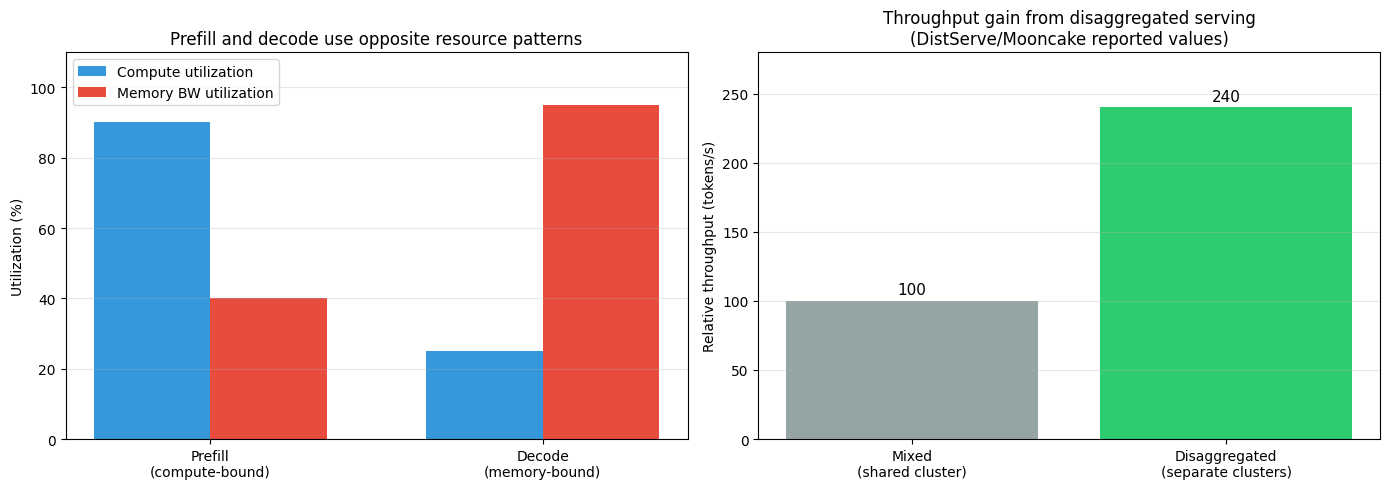

关键观察：Prefill/Decode 分离让两种计算模式各自打到最大利用率
代价：需要在 Prefill 和 Decode 集群之间传 KV cache，工程复杂度高


In [6]:
# Prefill vs Decode 的资源使用模式可视化

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 资源使用对比
ax = axes[0]
modes = ['Prefill\n(compute-bound)', 'Decode\n(memory-bound)']
compute_use = [90, 25]
memory_use = [40, 95]
x = range(len(modes))
width = 0.35
ax.bar([i - width/2 for i in x], compute_use, width, label='Compute utilization', color='#3498db')
ax.bar([i + width/2 for i in x], memory_use, width, label='Memory BW utilization', color='#e74c3c')
ax.set_xticks(list(x))
ax.set_xticklabels(modes)
ax.set_ylabel('Utilization (%)')
ax.set_title('Prefill and decode use opposite resource patterns')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
ax.set_ylim(0, 110)

# 混合 vs 分离
ax = axes[1]
configs = ['Mixed\n(shared cluster)', 'Disaggregated\n(separate clusters)']
throughputs = [100, 240]
bars = ax.bar(configs, throughputs, color=['#95a5a6', '#2ecc71'])
ax.set_ylabel('Relative throughput (tokens/s)')
ax.set_title('Throughput gain from disaggregated serving\n(DistServe/Mooncake reported values)')
ax.grid(True, axis='y', alpha=0.3)
for i, v in enumerate(throughputs):
    ax.text(i, v + 5, f'{v}', ha='center', fontsize=11)
ax.set_ylim(0, 280)

plt.tight_layout()
plt.show()

print("关键观察：Prefill/Decode 分离让两种计算模式各自打到最大利用率")
print("代价：需要在 Prefill 和 Decode 集群之间传 KV cache，工程复杂度高")

## 7. 主流推理引擎横评

把上面这些技术打包成生产可用的推理引擎，目前主流的几个：

| 引擎 | 来源 | 核心特性 | 典型场景 |
|:---|:---|:---|:---|
| **vLLM** | UC Berkeley | PagedAttention + Continuous batching | 通用、社区最活跃 |
| **SGLang** | UC Berkeley | RadixAttention（前缀树缓存）+ 结构化生成 | 多轮对话、agentic、复杂前缀复用 |
| **TensorRT-LLM** | NVIDIA | Hopper/Blackwell FP8 kernel 最优 | NVIDIA 卡上追求极致性能 |
| **LMDeploy** | OpenMMLab | Turbomind + W4A16 | 国产模型生态友好 |
| **TGI** | HuggingFace | HF Hub 紧耦合 | HF 生态用户 |
| **Mooncake** | Moonshot/Kimi | KV cache 中心化 + Prefill/Decode 分离 | 长上下文高并发 |

选择经验：通用场景 vLLM 是稳妥默认；agentic / 多轮场景 SGLang 更合适；NVIDIA 卡上追极致性能用 TensorRT-LLM；国产模型（Qwen、GLM、DeepSeek）用 LMDeploy 集成度好；DeepSeek 系列模型（用 MLA）目前 vLLM/SGLang 都有支持，但工程成熟度仍在追赶。

实际部署还要看模型架构。带 MLA、Mamba、linear attention 这些非标准组件的模型，需要确认推理引擎是否原生支持，否则要走 fallback 路径，性能掉一截。

## 小结

- [ ] LLM 服务的核心指标：吞吐（throughput）、TTFT、TPOT、并发数，互相牵制
- [ ] LLM 推理的瓶颈在显存带宽而非算力——这就是 KV Cache 大小为何如此重要
- [ ] 多请求下连续分配会带来内部碎片和外部碎片，PagedAttention 用 block table 解决
- [ ] Continuous batching 在 iteration 级别动态拼 batch，让短请求先结束、新请求立刻加入
- [ ] Prefix caching（RadixAttention）用 trie 组织请求序列，自动复用相同前缀的 KV cache
- [ ] Prefill 是 compute-bound、Decode 是 memory-bound，分离部署（Mooncake/DistServe）能显著提升吞吐
- [ ] 主流引擎：vLLM（通用）、SGLang（agentic）、TensorRT-LLM（NVIDIA 极致）、LMDeploy（国产模型）

参考：[vLLM/PagedAttention](https://arxiv.org/abs/2309.06180)、[SGLang/RadixAttention](https://arxiv.org/abs/2312.07104)、[Orca/Continuous batching](https://www.usenix.org/con/osdi22/presentation/yu)、[DistServe](https://arxiv.org/abs/2401.09670)、[Mooncake](https://arxiv.org/abs/2407.00079)。

## 作业

> 可以让 AI 帮忙解释思路，但不建议直接让 AI "做完这道题"。

**作业 1：KV Cache 容量计算**

给定：A100 80GB，Llama-7B FP16（权重 13 GB），block_size = 16 token。剩下的显存全用来做 KV cache。算一下：32K 上下文下，最多能同时服务多少个并发请求？（只考虑 KV cache 限制，忽略其他开销）

小提示：参考第 1 节的计算方式。每个并发请求需要 `seq_len × num_layers × num_heads × head_dim × 2 × bytes_per_element` 字节的 KV cache。剩余显存 = 80 - 13 = 67 GB。

In [7]:
# 作业 1：KV Cache 容量计算

gpu_total_gb = 80
model_weights_gb = 13
block_size = 16
seq_len = 32768
num_layers = 32
num_heads = 32
head_dim = 128
bytes_per_element = 2  # FP16

# TODO: 填入计算
available_gb = gpu_total_gb - model_weights_gb
kv_cache_per_request_gb = seq_len * num_layers * num_heads * head_dim * 2 * bytes_per_element / (1024**3)
max_concurrency = int(available_gb / kv_cache_per_request_gb)

assert available_gb is not None, "请先计算 available_gb"
assert kv_cache_per_request_gb is not None, "请先计算 kv_cache_per_request_gb"
assert max_concurrency is not None, "请先计算 max_concurrency"

expected_avail = 80 - 13
expected_kv = 32768 * 32 * 32 * 128 * 2 * 2 / (1024**3)
expected_max = int(expected_avail / expected_kv)

assert abs(available_gb - expected_avail) < 0.01
assert abs(kv_cache_per_request_gb - expected_kv) < 0.01
assert max_concurrency == expected_max

print(f"✅ 作业 1 通过")
print(f"   可用显存: {available_gb} GB")
print(f"   每请求 KV cache: {kv_cache_per_request_gb:.2f} GB")
print(f"   最大并发: {max_concurrency} 个请求")
print(f"   关键观察：这就是为什么需要 PagedAttention + Continuous batching——把并发拉满")

✅ 作业 1 通过
   可用显存: 67 GB
   每请求 KV cache: 16.00 GB
   最大并发: 4 个请求
   关键观察：这就是为什么需要 PagedAttention + Continuous batching——把并发拉满


**作业 2：实现简化 PagedAttention 的 allocate 方法**

下面是一个简化的 `SimplePagedAttention` 类，`allocate` 方法的实现省略了。补全：根据请求需要的 token 数算出 block 数，从 `free_blocks` 里取，记录到 `block_table`。

小提示：需要的 block 数 = `(num_tokens + block_size - 1) // block_size`（向上取整）。如果 `free_blocks` 不够，raise MemoryError。

In [8]:
# 作业 2：补全 PagedAttention 的 allocate

class SimplePagedAttention:
    def __init__(self, num_blocks, block_size):
        self.num_blocks = num_blocks
        self.block_size = block_size
        self.free_blocks = list(range(num_blocks))
        self.block_table = {}

    def allocate(self, req_id, num_tokens):
        # 1. 算需要多少块（向上取整）
        n_blocks = (num_tokens + self.block_size - 1) // self.block_size
        # 2. 如果不够，raise MemoryError
        if n_blocks > len(self.free_blocks):
            raise MemoryError(f"not enough free blocks: need {n_blocks}, have {len(self.free_blocks)}")
        # 3. 从 free_blocks 取出对应数量的块
        blocks = self.free_blocks[:n_blocks]
        self.free_blocks = self.free_blocks[n_blocks:]
        # 4. 记到 block_table[req_id]
        self.block_table[req_id] = blocks
        # 5. return 这些块
        return blocks


# 验证
pa = SimplePagedAttention(num_blocks=10, block_size=16)
b1 = pa.allocate("A", 50)
b2 = pa.allocate("B", 20)
assert len(b1) == 4, f"A 需要 4 块（50/16 向上取整），实际 {len(b1)}"
assert len(b2) == 2, f"B 需要 2 块（20/16 向上取整），实际 {len(b2)}"
assert len(pa.free_blocks) == 4, f"应剩 4 块，实际 {len(pa.free_blocks)}"

# 第三个请求需要的块数超过剩余
try:
    pa.allocate("C", 200)  # 需要 13 块，但只剩 4 块
    assert False, "应该 raise MemoryError"
except MemoryError:
    pass

print(f"✅ 作业 2 通过")
print(f"   A 分配: {b1}")
print(f"   B 分配: {b2}")
print(f"   剩余空闲块: {pa.free_blocks}")

✅ 作业 2 通过
   A 分配: [0, 1, 2, 3]
   B 分配: [4, 5]
   剩余空闲块: [6, 7, 8, 9]


**作业 3：Prefix cache 命中率计算**

给定一组请求的 token 序列（每个是 token id 列表），用下面提供的 `SimplePrefixCache`，算出全部请求处理完后**总命中率**（命中 token 数 / 总 token 数）。

小提示：依次调用 `lookup_and_insert`，累加每次返回的命中长度。

In [9]:
# 作业 3：Prefix cache 命中率计算

class SimplePrefixCache:
    def __init__(self):
        self.tree = {}

    def lookup_and_insert(self, tokens):
        node = self.tree
        hit_len = 0
        for i, tok in enumerate(tokens):
            if tok in node:
                node = node[tok]
                hit_len += 1
            else:
                for t in tokens[i:]:
                    node[t] = {}
                    node = node[t]
                break
        return hit_len


# 3 个请求，第一个是基础 prompt，后两个共享前缀
system_prompt = list(range(200))   # 200 token 的 system prompt
req1 = system_prompt + [1000 + i for i in range(50)]
req2 = system_prompt + [2000 + i for i in range(80)]
req3 = system_prompt + [3000 + i for i in range(100)]

all_reqs = [req1, req2, req3]

cache = SimplePrefixCache()

# TODO: 算总命中数和总 token 数
total_hits = sum(cache.lookup_and_insert(r) for r in all_reqs)
total_tokens = sum(len(r) for r in all_reqs)
hit_rate = total_hits / total_tokens

assert total_hits is not None
assert total_tokens is not None
assert hit_rate is not None

# 验证
expected_total = sum(len(r) for r in all_reqs)
# req1 全 miss（200 + 50 = 250 token，全部新建，hit=0 因为第一次插入）
# 等等——lookup_and_insert 在第一次插入时也会返回 hit_len，即匹配上的部分
# req1: 全新插入，hit=0
# req2: 前 200 token 已存在，hit=200
# req3: 前 200 token 已存在，hit=200
expected_hits = 0 + 200 + 200
expected_rate = expected_hits / expected_total

assert total_tokens == expected_total, f"应为 {expected_total}"
assert total_hits == expected_hits, f"应为 {expected_hits}"
assert abs(hit_rate - expected_rate) < 0.001

print(f"✅ 作业 3 通过")
print(f"   总 token 数: {total_tokens}")
print(f"   命中 token 数: {total_hits}")
print(f"   命中率: {hit_rate*100:.1f}%")
print(f"   关键观察：共享前缀的请求越多，命中率越高，省的 prefill 算力越多")

✅ 作业 3 通过
   总 token 数: 830
   命中 token 数: 400
   命中率: 48.2%
   关键观察：共享前缀的请求越多，命中率越高，省的 prefill 算力越多
